# Monte Carlo Methods

## Setting up the model

Arithmetic Asian call option:

$\bar{S}=\frac{1}{n}\sum^n_{i=1}S(t_i)$

Geometric Asian call option:

$\bar{S}=\left(\prod^n_{i=1} S(t_i)\right)^{\frac{1}{n}}$

The payoff's for each are then calculated as $\bar{S}-K$



The CEV model:



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.stats.qmc import Sobol
from scipy.stats import norm, t

In [2]:
# Drawing pseudo-random numbers
def draw_pseudo_random_numbers(seed, N, M):
    rng = np.random.default_rng(seed)
    return rng.standard_normal(size=(N, M))

def draw_quasi_random_numbers(seed, N, M):
    m = int(np.ceil(np.log2(N)))
    if 2**m != N:
        raise ValueError("For Sobol QMC, set N to 2**m.")
    sobol_engine = Sobol(d=M, scramble=True, seed=seed)
    U = sobol_engine.random_base2(m=m)  # 2^20 
    return norm.ppf(np.clip(U, 1e-12, 1-1e-12)) # avoid inf values


def draw_pseudo_antithetic_numbers(seed, N, M):
    """Generate N standard normal variates in M dimensions using antithetic pairing."""
    rng = np.random.default_rng(seed)
    half_N = (N + 1) // 2  # Handle both even and odd N
    Z_half = rng.standard_normal(size=(half_N, M))
    # Stack Z and -Z, then take first N rows (handles odd N)
    Z = np.vstack([Z_half, -Z_half])[:N]
    return Z

In [3]:
# Simulating paths
def sim_CEV_paths(seed, S0, r, sigma, gamma, T, M, N, euler=True, quasi=False, Z=None):
    dt = T / M 
    sqrt_dt = np.sqrt(dt)
    logS = np.empty((N, M+1), dtype=float)
    logS[:, 0] = np.log(S0)

    if Z is None:
        Z = draw_quasi_random_numbers(seed, N, M) if quasi else draw_pseudo_random_numbers(seed, N, M)
        
    for n in range(M):
        logS_n = logS[:, n]
        S_n = np.exp(logS_n)
        dW = sqrt_dt * Z[:, n]
        # Ito's lemma for log S_t in CEV: d log S = (r - 0.5 * sigma^2 * S^{2gamma-2}) dt + sigma * S^{gamma-1} dW
        drift = (r - 0.5 * sigma**2 * np.power(S_n, 2*gamma-2)) * dt
        diffusion = sigma * np.power(S_n, gamma-1) * dW
        if euler:
            logS[:, n+1] = logS_n + drift + diffusion
        else:
            correction = 0.5 * sigma**2 * (gamma - 1) * np.power(S_n, 2*gamma-2) * (dW**2 - dt)
            logS[:, n+1] = logS_n + drift + diffusion + correction
    return np.exp(logS)


def price_asian_option_from_Z(Z, S0, K, r, sigma, gamma, T, M, euler=True):
    N = Z.shape[0]
    S = sim_CEV_paths(seed=0, S0=S0, r=r, sigma=sigma, gamma=gamma,
                      T=T, M=M, N=N, euler=euler, quasi=True, Z=Z)
    avg = S[:, 1:].mean(axis=1)  # average over time steps (exclude initial)
    disc_payoff = np.exp(-r * T) * np.maximum(avg - K, 0.0)
    return float(disc_payoff.mean())


def ci_from_replicates(estimates, alpha=0.05):
    est = np.asarray(estimates, dtype=float)
    K = est.size
    mean = est.mean()
    # sample variance of replicate means
    var_between = est.var(ddof=1) if K > 1 else np.nan
    se_mean = np.sqrt(var_between / K) if K > 1 else np.nan
    # t critical (falls back to normal if K large)
    df = K - 1
    if K > 1:
        tcrit = t.ppf(1 - alpha/2, df=df)
        ci = (mean - tcrit * se_mean, mean + tcrit * se_mean)
    else:
        ci = (np.nan, np.nan)
    return mean, se_mean, ci, var_between

def rqmc_with_scrambles(seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_q, euler=True):
    estimates = []
    for s in range(scrambles):
        estimates.append(price_asian_option_from_Z(Z_q[s], S0, K, r, sigma, gamma, T, M, euler))
    mean, se, ci, var_between = ci_from_replicates(estimates)

    return mean, se, ci, var_between, np.array(estimates, dtype=float)


def mc_with_batches(seed, batches, S0, K, r, sigma, gamma, T, M, N, Z_m, euler=True):
    estimates = []
    for b in range(batches):
        estimates.append(price_asian_option_from_Z(Z_m[b], S0, K, r, sigma, gamma, T, M, euler))
    mean, se, ci, var_between = ci_from_replicates(estimates)
    return mean, se, ci, var_between, np.array(estimates)


def mc_with_antithetic(seed, batches, S0, K, r, sigma, gamma, T, M, N, euler=True):
    """Run Monte Carlo using antithetic variates for variance reduction."""
    estimates = []
    for b in range(batches):
        # Generate antithetic pairs
        Z = draw_pseudo_antithetic_numbers(seed + b, N, M)
        # Price using the antithetic samples
        price = price_asian_option_from_Z(Z, S0, K, r, sigma, gamma, T, M, euler)
        estimates.append(price)
    
    mean, se, ci, var_between = ci_from_replicates(estimates)
    return mean, se, ci, var_between, np.array(estimates)

In [4]:
S0, K, r, sigma, gamma, T, M = 100, 100, 0.05, 2.0, 0.7, 1.0, 252
N         = 2**18          # keep as power of two
base_seed = 42
scrambles = 8

Z_m = []
Z_q = []
Z_anti = []

for b in range(scrambles):
    Z_m.append(draw_pseudo_random_numbers(base_seed + b, N, M))
    Z_q.append(draw_quasi_random_numbers(base_seed + b, N, M))
    Z_anti.append(draw_pseudo_antithetic_numbers(base_seed + b, N, M))
    #print(b)

KeyboardInterrupt: 

In [5]:
mean_q, se_q, ci_q, var_q, _ = rqmc_with_scrambles(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_q, euler=True)


In [6]:
mean_m, se_m, ci_m, var_m, _ = mc_with_batches(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_m, euler=True)

In [7]:
print(f"MC Estimate: {mean_m:.6f}, SE: {se_m:.6f}, Var: {var_m:.6f} over {scrambles} batches")
print(f"RQMC Estimate: {mean_q:.6f}, SE: {se_q:.6f}, Var: {var_q:.6f} over {scrambles} scrambles")

MC Estimate: 12.434399, SE: 0.016789, Var: 0.002255 over 8 batches
RQMC Estimate: 12.430253, SE: 0.001899, Var: 0.000029 over 8 scrambles


In [21]:
euler= mc_with_batches(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_m, euler=True)
milstein = mc_with_batches(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_m, euler=False)
mean_anti, se_anti, ci_anti, var_anti, _ = mc_with_antithetic(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, euler=True)

In [23]:
print("Using Milstein scheme:")
print(f"Asian Call Option Price: {milstein[0]:.4f}")
print(f"Standard Error: {milstein[1]:.8f}")
print(f"95% Confidence Interval: ({milstein[2][0]:.4f}, {milstein[2][1]:.4f})\n")

print("Using Euler scheme:")
print(f"Asian Call Option Price: {euler[0]:.4f}")
print(f"Standard Error: {euler[1]:.8f}")
print(f"95% Confidence Interval: ({euler[2][0]:.4f}, {euler[2][1]:.4f})")

print(f"Antithetic MC: mean {mean_anti:.6f}, se {se_anti:.6f}, ci [{ci_anti[0]}, {ci_anti[1]}], var {var_anti:.6f}")

Using Milstein scheme:
Asian Call Option Price: 12.4306
Standard Error: 0.01680077
95% Confidence Interval: (12.3909, 12.4703)

Using Euler scheme:
Asian Call Option Price: 12.4344
Standard Error: 0.01678893
95% Confidence Interval: (12.3947, 12.4741)
Antithetic MC: mean 12.446331, se 0.010506, ci [12.421487533968586, 12.471174804460931], var 0.000883


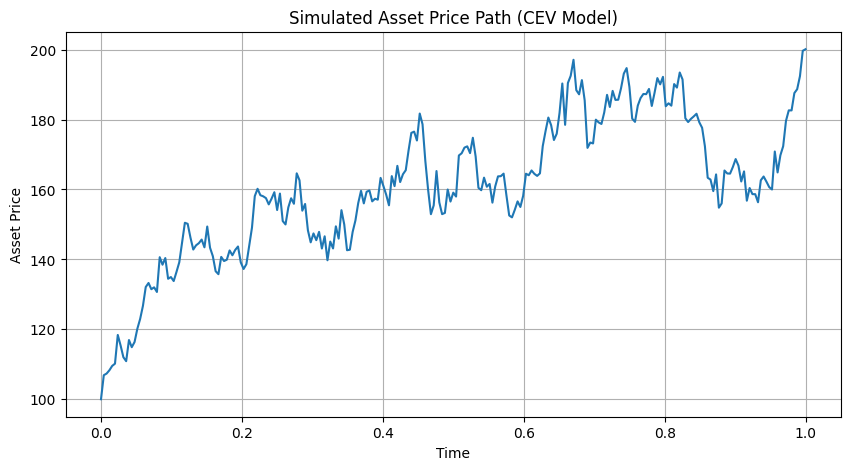

In [19]:
# Simulate one path and plot its movement
S_single = sim_CEV_paths(base_seed, S0, r, sigma, gamma, T, M, 100)[98]
plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, T, M+1), S_single)
plt.xlabel("Time")
plt.ylabel("Asset Price")
plt.title("Simulated Asset Price Path (CEV Model)")
plt.grid(True)
plt.show()

Running for N = 1
Running for N = 10
Running for N = 100
Running for N = 1000
Running for N = 5000
Running for N = 10000
Running for N = 50000
Running for N = 100000
Running for N = 250000
Running for N = 500000
Running for N = 750000
Running for N = 1000000


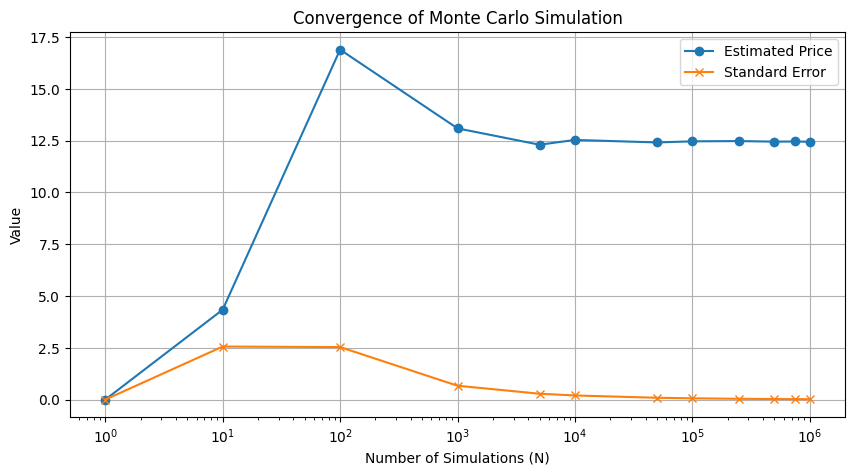

In [10]:
# plotting convergence
N_values = [1, 10, 100, 1000, 5000, 10000, 50000, 100000, 250000, 500000, 750000, 1000000]
prices = []
errors = []

for N in N_values:
    print(f"Running for N = {N}")
    
    # Generate single batch of random numbers for this N
    Z_single = [draw_pseudo_random_numbers(base_seed, N, M)]
    
    # Get the price from existing function
    price, _, _, _, estimates = mc_with_batches(base_seed, 1, S0, K, r, sigma, gamma, T, M, N, Z_single, euler=True)
    
    # Calculate standard error from the individual simulations
    # We need to get the individual payoffs, so let's calculate them directly
    S = sim_CEV_paths(seed=0, S0=S0, r=r, sigma=sigma, gamma=gamma,
                      T=T, M=M, N=N, euler=True, quasi=False, Z=Z_single[0])
    avg_prices = S[:, 1:].mean(axis=1)  # average over time steps (exclude initial)
    payoffs = np.maximum(avg_prices - K, 0.0)
    discounted_payoffs = np.exp(-r * T) * payoffs
    
    se = discounted_payoffs.std() / np.sqrt(N)  # Standard error of the mean
    
    prices.append(price)
    errors.append(se)
    #print(f"  Price: {price:.6f}, SE: {se:.8f}")

plt.figure(figsize=(10, 5))
plt.plot(N_values, prices, marker='o', label='Estimated Price')
plt.plot(N_values, errors, marker='x', label='Standard Error')
plt.xscale('log')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Value')
plt.title('Convergence of Monte Carlo Simulation')
plt.legend()
plt.grid(True)
plt.show()

Running MC vs QMC comparison for N = 256
Running MC vs QMC comparison for N = 512
Running MC vs QMC comparison for N = 1024
Running MC vs QMC comparison for N = 2048
Running MC vs QMC comparison for N = 4096
Running MC vs QMC comparison for N = 8192
Running MC vs QMC comparison for N = 16384
Running MC vs QMC comparison for N = 32768
Running MC vs QMC comparison for N = 65536
Running MC vs QMC comparison for N = 131072


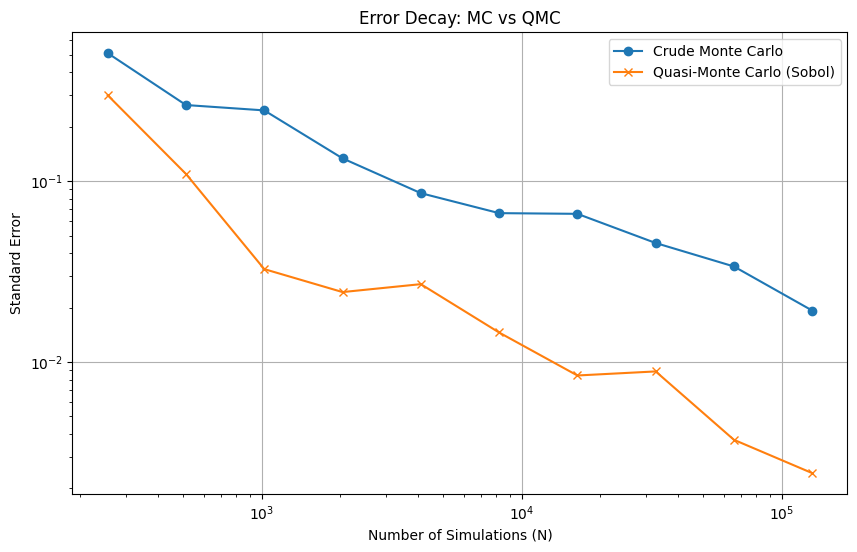

In [11]:
# Powers of 2 for Sobol
N_values = [2**i for i in range(8, 18)]  # 256 to 131072
mc_errors = []
qmc_errors = []

for N in N_values:
    print(f"Running MC vs QMC comparison for N = {N}")
    
    # Generate fresh random numbers for this specific N
    Z_m_temp = []
    Z_q_temp = []
    
    for b in range(scrambles):
        Z_m_temp.append(draw_pseudo_random_numbers(base_seed + b, N, M))
        Z_q_temp.append(draw_quasi_random_numbers(base_seed + b, N, M))
    
    # Calculate standard errors using multiple scrambles/batches
    _, mc_se, _, _, _ = mc_with_batches(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_m_temp, euler=False)
    _, qmc_se, _, _, _ = rqmc_with_scrambles(base_seed, scrambles, S0, K, r, sigma, gamma, T, M, N, Z_q_temp, euler=False)
    
    mc_errors.append(mc_se)
    qmc_errors.append(qmc_se)
    #print(f"  MC SE: {mc_se:.8f}, QMC SE: {qmc_se:.8f}")

plt.figure(figsize=(10, 6))
plt.plot(N_values, mc_errors, marker='o', label='Crude Monte Carlo')
plt.plot(N_values, qmc_errors, marker='x', label='Quasi-Monte Carlo (Sobol)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Standard Error')
plt.title('Error Decay: MC vs QMC')
plt.legend()
plt.grid(True)
plt.show()

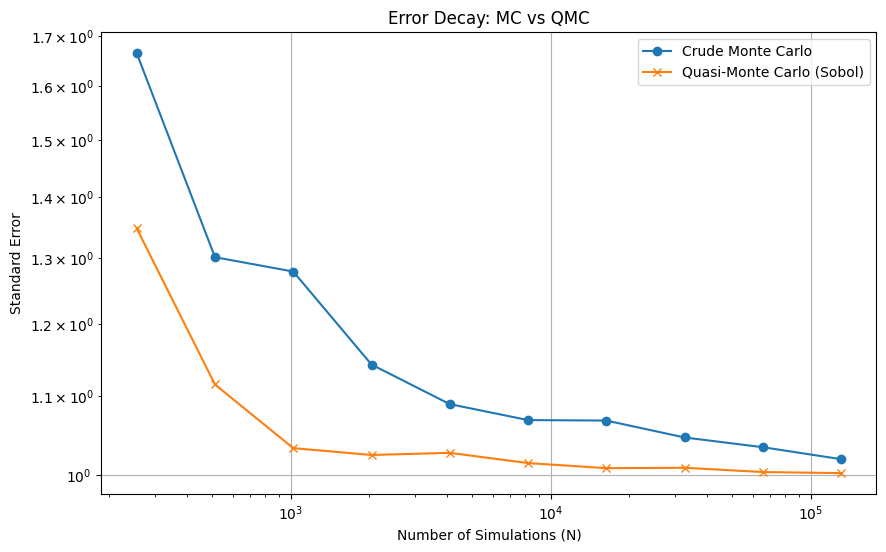

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(N_values, np.exp(mc_errors), marker='o', label='Crude Monte Carlo')
plt.plot(N_values, np.exp(qmc_errors), marker='x', label='Quasi-Monte Carlo (Sobol)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Standard Error')
plt.title('Error Decay: MC vs QMC')
plt.legend()
plt.grid(True)
plt.show()


=== Comparison with M=52 (weekly time steps) ===
Running MC vs QMC comparison for N = 256, M = 52
Running MC vs QMC comparison for N = 512, M = 52
Running MC vs QMC comparison for N = 1024, M = 52
Running MC vs QMC comparison for N = 2048, M = 52
Running MC vs QMC comparison for N = 4096, M = 52
Running MC vs QMC comparison for N = 8192, M = 52
Running MC vs QMC comparison for N = 16384, M = 52
Running MC vs QMC comparison for N = 32768, M = 52


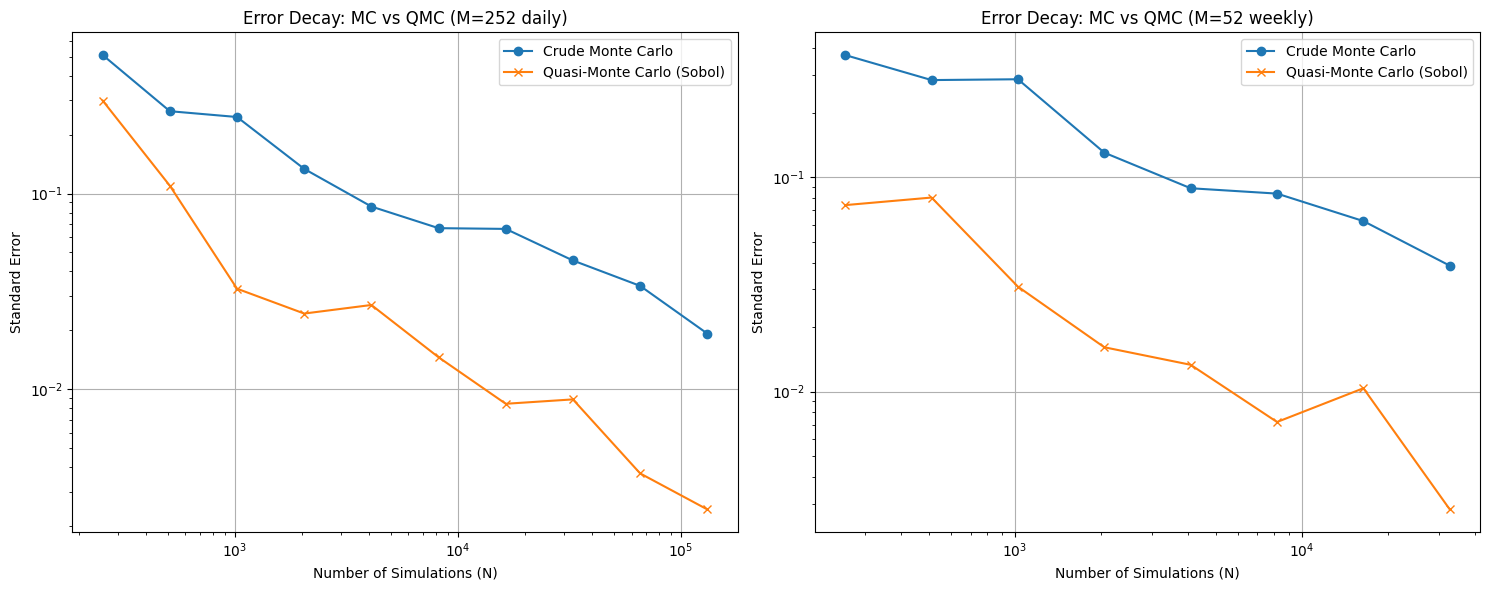

In [13]:
# Let's also try with fewer time steps to see QMC advantage more clearly
M_low = 52  # Weekly instead of daily
N_values_low = [2**i for i in range(8, 16)]  # Smaller range for faster computation
mc_errors_low = []
qmc_errors_low = []

print("\n=== Comparison with M=52 (weekly time steps) ===")
for N in N_values_low:
    print(f"Running MC vs QMC comparison for N = {N}, M = {M_low}")
    
    # Generate fresh random numbers for this specific N and M
    Z_m_temp = []
    Z_q_temp = []
    
    for b in range(scrambles):
        Z_m_temp.append(draw_pseudo_random_numbers(base_seed + b + 100, N, M_low))
        Z_q_temp.append(draw_quasi_random_numbers(base_seed + b + 100, N, M_low))
    
    # Calculate standard errors
    _, mc_se, _, _, _ = mc_with_batches(base_seed, scrambles, S0, K, r, sigma, gamma, T, M_low, N, Z_m_temp, euler=False)
    _, qmc_se, _, _, _ = rqmc_with_scrambles(base_seed, scrambles, S0, K, r, sigma, gamma, T, M_low, N, Z_q_temp, euler=False)
    
    mc_errors_low.append(mc_se)
    qmc_errors_low.append(qmc_se)
    #print(f"  MC SE: {mc_se:.8f}, QMC SE: {qmc_se:.8f}, QMC advantage: {mc_se/qmc_se:.2f}x")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original with M=252
ax1.plot(N_values, mc_errors, marker='o', label='Crude Monte Carlo')
ax1.plot(N_values, qmc_errors, marker='x', label='Quasi-Monte Carlo (Sobol)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Number of Simulations (N)')
ax1.set_ylabel('Standard Error')
ax1.set_title(f'Error Decay: MC vs QMC (M={M} daily)')
ax1.legend()
ax1.grid(True)

# Lower dimensional with M=52
ax2.plot(N_values_low, mc_errors_low, marker='o', label='Crude Monte Carlo')
ax2.plot(N_values_low, qmc_errors_low, marker='x', label='Quasi-Monte Carlo (Sobol)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Simulations (N)')
ax2.set_ylabel('Standard Error')
ax2.set_title(f'Error Decay: MC vs QMC (M={M_low} weekly)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()